In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import ipywidgets as w
from IPython.display import clear_output
from io import StringIO


data = pd.read_csv('/Users/rodericktimmerman/workspace/PrometheusDataAnalysis/run0-2025-04-17.1.csv')
area = np.zeros((1600, 1600))

scaling = 4 / 2.0

x = lambda r: int(((r + scaling)/(scaling * 2)) * 1599)
y = lambda i: int(((i + scaling)/(scaling * 2)) * 1599)

for idx, row in data.iterrows():
    area[x(row['r'])][y(row['i'])] = row['value']

fig = plt.figure()
fig.set_size_inches(12, 12)
ax = fig.add_subplot(1, 1, 1)
# # ax.get_figure().set_size_inches(7, 7)
# ax.spines['left'].set_position('center')
# ax.spines['bottom'].set_position('center')
# ax.spines['top'].set_color('none')
# ax.spines['right'].set_color('none')

ax.set_axis_off()
# ax.grid(linestyle='dotted')
# ax.locator_params(axis='x', nbins = 4)
# ax.locator_params(axis='y', nbins = 4)

plt.imshow(area.T, cmap = plt.colormaps['BuPu_r'])
plt.show()

# def run(b):
#     global uploader
#     render(pd.read_csv(StringIO("csv string")))

# uploader = w.FileUpload(multiple=False)
# # t = w.Text()
# run_button = w.Button(description='Run', icon='play')
# run_button.on_click(run)
# h_box = w.HBox([uploader, run_button])
# display(h_box)

ModuleNotFoundError: No module named 'secrets'

----


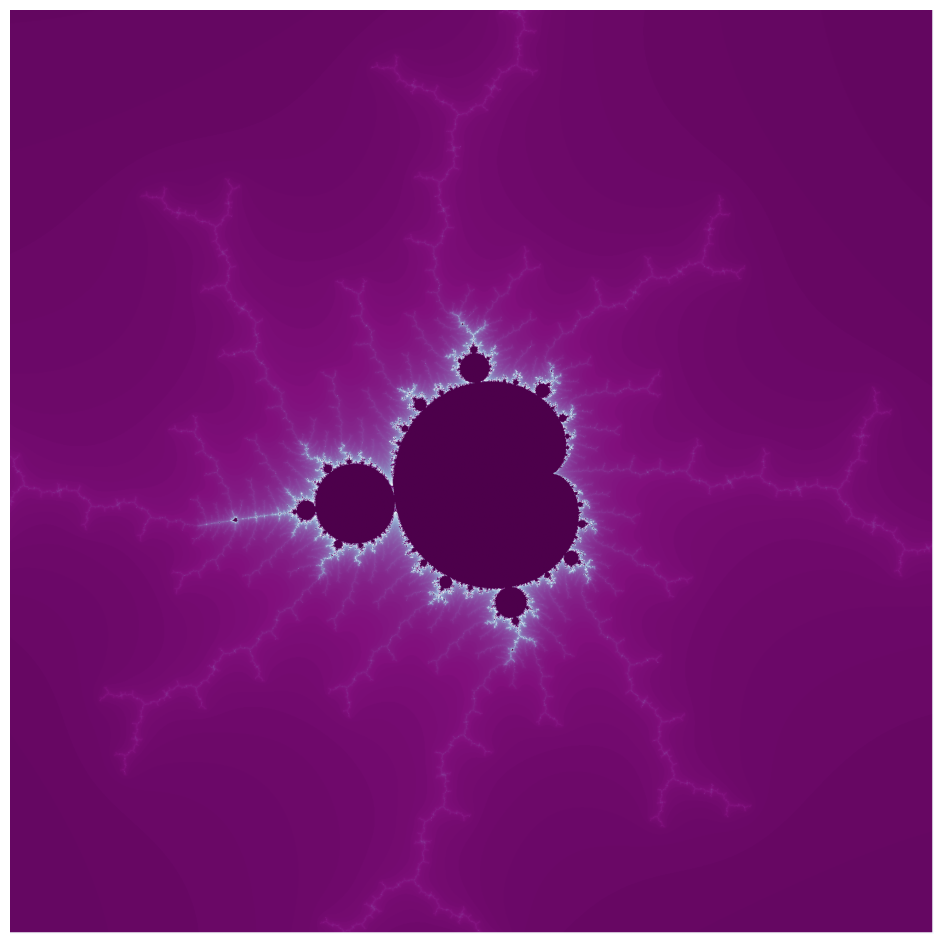

In [94]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.colors as colors


# ds = pd.read_csv('/Users/rodericktimmerman/workspace/PrometheusDataAnalysis/run0-2025-03-27.csv')
# ds = pd.read_csv('/Users/rodericktimmerman/workspace/PrometheusDataAnalysis/run0-2025-03-27-1.csv')
# ds = pd.read_csv('/Users/rodericktimmerman/workspace/PrometheusDataAnalysis/run0-2025-05-06.1.csv')
# ds = pd.read_csv('/Users/rodericktimmerman/workspace/PrometheusDataAnalysis/run0-2025-05-13.3.csv') # deep zoom w. structure
ds = pd.read_csv('/Users/rodericktimmerman/workspace/PrometheusDataAnalysis/run0-2025-05-18.2.csv') # too deep a zoom (blank field after an hour!)

ball = (1604, 1604)
space = np.zeros(ball)

df = ds.sort_values(['i', 'r'], ascending=True)
# print(df.iloc[500000, :])

annotation_point = None
annotation_coords = -0.19821982198219823-1.1003100310031004j
annotation_ball = 1e-2
# print(df.head())

# Plotting row by row...
# for i in range(ball[1]):
#     for r in range(ball[0]):
#         space[i][r] = df.iloc[r + (i * (ball[1])), 2] % 400

# Plotting by transforming coordinates
min_r, max_r = np.min(df["r"]), np.max(df["r"])
min_i, max_i = np.min(df["i"]), np.max(df["i"])

conv_r = lambda x: (1600 * (x - min_r)) / (max_r - min_r)
conv_i = lambda x: (1600 * (x - min_i)) / (max_i - min_i)

# print(df.head())

scale = 10
for entry in df.iterrows():
    x, y = int(np.round(conv_r(entry[1].r))), int(np.round(conv_i(entry[1].i)))
    space[y][x] = entry[1].value % 200
    # y = np.abs(min_i) + entry[1].i
print('----')
# print(space[100][100])
fig = plt.figure()

fig.set_size_inches(12, 12)
ax = fig.add_subplot(1, 1, 1)
# # ax.get_figure().set_size_inches(7, 7)
# ax.spines['left'].set_position('center')
# ax.spines['bottom'].set_position('center')
# ax.spines['top'].set_color('none')
# ax.spines['right'].set_color('none')
# print(annotation_point)
ax.grid(linestyle='dotted')
ax.locator_params(axis='x', nbins = 4)
ax.locator_params(axis='y', nbins = 4)

# ax.annotate('x', xy=annotation_point)
ax.set_axis_off()
ax.imshow(space, cmap = 'BuPu')

# cmap = colors.LinearSegmentedColormap.from_list('a', plt.get_cmap('bone_r')(np.linspace(.2, .4, 1000)))
# cmap = colors.LinearSegmentedColormap.from_list()

# plt.imshow(space, cmap = 'BuPu')#, norm=colors.Normalize(vmin=-1, vmax=5000))
plt.show()
